In [1]:
"""
This notebook is used to verify the configurator.py file.
"""

%load_ext autoreload
%autoreload 2

In [2]:
import torch
from torch.utils.data import TensorDataset, DataLoader

from tqdm import tqdm

import matplotlib.pyplot as plt

from escnn import gspaces
from escnn import nn

import numpy as np
np.set_printoptions(precision=3, linewidth=10000, suppress=True)

In [3]:
r2_act = gspaces.rot2dOnR2(N=10)

feat_type_in = nn.FieldType(r2_act, [r2_act.trivial_repr])
feat_type_hid = nn.FieldType(r2_act, 8*[r2_act.regular_repr])
feat_type_out = nn.FieldType(r2_act, [r2_act.regular_repr])

model = nn.SequentialModule(
    nn.R2Conv(feat_type_in, feat_type_hid, kernel_size=3),
    nn.InnerBatchNorm(feat_type_hid),
    nn.ReLU(feat_type_hid),
    nn.R2Conv(feat_type_hid, feat_type_hid, kernel_size=3),
    nn.InnerBatchNorm(feat_type_hid),
    nn.ReLU(feat_type_hid),
    nn.R2Conv(feat_type_hid, feat_type_out, kernel_size=3),
).eval().to('cuda')

avgpool = nn.PointwiseAvgPool(feat_type_out, 11).to('cuda')

inv_map = nn.GroupPooling(feat_type_out).to('cuda')

In [4]:
data = torch.load('/pscratch/sd/z/zhantao/neurorient_repo/data/PR772/PR772_neurorient_downsampled_128x128.pt')
images = data['intensities'].unsqueeze(1)
images /= images.mean(dim=(-2,-1), keepdim=True)

In [5]:
images_dataset = TensorDataset(images)
images_dataloader = DataLoader(images_dataset, batch_size=100)

In [6]:
image_inv_feats = []

for batch in tqdm(images_dataloader):
    x = feat_type_in(batch[0].to('cuda'))

    y = inv_map(avgpool(model(x))).tensor.detach().cpu().numpy().reshape(x.shape[0],-1)
    
    image_inv_feats.append(y)
    # break
    
image_inv_feats = np.vstack(image_inv_feats)  

100%|██████████| 148/148 [00:09<00:00, 15.19it/s]


In [7]:
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans

In [8]:
n_components = 2  # Number of principal components to keep
pca = PCA(n_components=n_components)
image_inv_feats_pca = pca.fit_transform(image_inv_feats)

/pscratch/sd/z/zhantao/conda/om/lib/python3.9/site-packages/sklearn/cluster/_kmeans.py:1412: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)


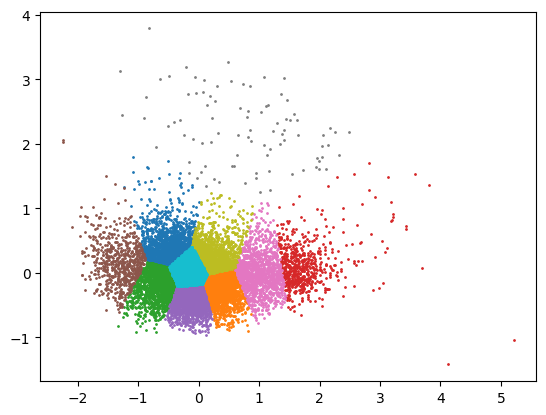

In [10]:
from sklearn.cluster import KMeans

# Assuming you want a certain number of clusters, which can depend on B_final
num_clusters = 10  # Example, adjust based on your requirement
kmeans = KMeans(n_clusters=num_clusters, random_state=42)
labels = kmeans.fit_predict(image_inv_feats_pca)

for i in range(num_clusters):
    plt.scatter(image_inv_feats_pca[labels==i,0], image_inv_feats_pca[labels==i,1], s=1)

In [11]:
B_final = image_inv_feats.shape[0] // 2  # The final number of images you want
samples_per_cluster = B_final // num_clusters

final_images_indices = []

for i in range(num_clusters):
    # Find indices of all images in this cluster
    indices = np.where(labels == i)[0]
    print(f"# of samples for cluster {i}: {len(indices)}")
    # If there are not enough images in the cluster, take all samples
    if len(indices) < samples_per_cluster:
        sampled_indices = indices
    else:
        sampled_indices = np.random.choice(indices, size=samples_per_cluster, replace=False)
    
    final_images_indices.extend(sampled_indices)

final_images_indices = np.array(final_images_indices)
final_images = data['intensities'][final_images_indices]

# of samples for cluster 0: 1830
# of samples for cluster 1: 2049
# of samples for cluster 2: 1784
# of samples for cluster 3: 635
# of samples for cluster 4: 1936
# of samples for cluster 5: 651
# of samples for cluster 6: 1374
# of samples for cluster 7: 91
# of samples for cluster 8: 1664
# of samples for cluster 9: 2758


In [12]:
import time, os

save_dir = '/pscratch/sd/z/zhantao/neurorient_repo/data/PR772'

pt_fpath = os.path.join(save_dir, f'PR772_neurorient_downsampled_128x128_filtered.pt')
torch.save(
    {
        'orientations': None,
        'intensities': final_images.float(),
        'pixel_position_reciprocal': data['pixel_position_reciprocal'],
        'pixel_index_map': data['pixel_index_map'],
        'volume': None,
        'img_real_mesh': data['img_real_mesh'],
        'vol_real_mesh': data['vol_real_mesh'],
        'time_stamp': time.strftime("%Y%m%d-%H%M")
    }, pt_fpath
)
print("data wrote to: \n", pt_fpath)

data wrote to: 
 /pscratch/sd/z/zhantao/neurorient_repo/data/PR772/PR772_neurorient_downsampled_128x128_filtered.pt
